# Определение возрастной категории пользователей по цифровому поведению

**Многоклассовая классификация · рекламная сеть «Йети» (РСЙ)**

работу выполнил **Жгенти Сергей**

## Подготовка среды и библиотек

### Выгрузка библиотек

In [1]:
%%writefile requirements.txt
pandas>=2.0,<2.2
numpy>=1.24,<2.0
scikit-learn>=1.4
matplotlib>=3.7
seaborn>=0.13
joblib>=1.3
phik>=0.12

Overwriting requirements.txt


In [2]:
!pip install phik

In [3]:
# Работа с данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Разбиение данных, кросс-валидация, подбор гиперпараметров
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate

# Пайплайны и предобработка
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Метрики
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

# φK-корреляция
from phik.report import plot_correlation_matrix

# Сохранение артефактов и перезагрузка модулей
import joblib
import importlib

# Отключение лишних предупреждений
import warnings
warnings.filterwarnings('ignore')

In [4]:
! python --version

Python 3.13.9


### Константы

In [5]:
RANDOM_STATE = 627
TEST_SIZE = 0.25
N_FOLDS = 5
CLASSES = [0, 1, 2, 3, 4]
F1_THRESHOLD = 0.75

### Загрузка данных

Данные хранятся в пяти таблицах, связанных по `user_id`:

- **`users`** — целевая переменная `age_category` (5 возрастных классов);
- **`visits`** — лог посещений сайтов (категория сайта, время суток, сессия) для генерации признаков;
- **`surf_depth`** — глубина сёрфинга пользователя (`поверхностно` / `средне` / `глубоко`);
- **`primary_device`** — основное устройство пользователя;
- **`cloud_usage`** — признак использования облачных сервисов (`True` / `False`).

In [6]:
def load_data(filename):
    """
    Загружает CSV с обработкой двух расположений:
    - путь на платформе Практикума ('/datasets/...');
    - локальный путь (текущая папка).
    """
    try:
        return pd.read_csv(f'/datasets/{filename}')
    except FileNotFoundError:
        return pd.read_csv(filename)


# Загрузка всех пяти таблиц
users          = load_data('ds_s13_users.csv')
visits         = load_data('ds_s13_visits.csv')
surf_depth     = load_data('surf_depth.csv')
primary_device = load_data('primary_device.csv')
cloud_usage    = load_data('cloud_usage.csv')

print('Размеры загруженных таблиц:')
print(f'  users         : {users.shape}')
print(f'  visits        : {visits.shape}')
print(f'  surf_depth    : {surf_depth.shape}')
print(f'  primary_device: {primary_device.shape}')
print(f'  cloud_usage   : {cloud_usage.shape}')

Размеры загруженных таблиц:
  users         : (5913, 2)
  visits        : (1065745, 5)
  surf_depth    : (5715, 2)
  primary_device: (5669, 2)
  cloud_usage   : (5680, 2)


## Первичный анализ и предобработка данных
Изучим структуру каждой таблицы, проверим типы данных, пропуски и дубликаты. По результатам осмотра выполним очистку, а затем перейдём к исследовательскому анализу и генерации признаков.

### Общий осмотр таблиц

In [7]:
print('=== Таблица users ===')
users.info()
print('\nПервые строки:')
display(users.head())
print('\nПропуски:')
print(users.isnull().sum())
print(f'\nПолных дубликатов строк: {users.duplicated().sum()}')
print(f'Дубликатов user_id: {users["user_id"].duplicated().sum()}')

=== Таблица users ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB

Первые строки:


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0



Пропуски:
user_id         0
age_category    0
dtype: int64

Полных дубликатов строк: 87
Дубликатов user_id: 87


In [8]:
print('=== Таблица visits ===')
visits.info()
print('\nПервые строки:')
display(visits.head())
print('\nПропуски:')
print(visits.isnull().sum())
print(f'\nПолных дубликатов строк: {visits.duplicated().sum()}')

=== Таблица visits ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB

Первые строки:


,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05



Пропуски:
date                0
daytime             0
session_id          0
user_id             0
website_category    0
dtype: int64

Полных дубликатов строк: 15750


In [9]:
for name, df in [('surf_depth', surf_depth),
                 ('primary_device', primary_device),
                 ('cloud_usage', cloud_usage)]:
    print(f'=== Таблица {name} ===')
    df.info()
    print('Пропуски:', df.isnull().sum().to_dict())
    print('Полных дубликатов:', df.duplicated().sum())
    print('Дубликатов user_id:', df['user_id'].duplicated().sum())
    print()

=== Таблица surf_depth ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB
Пропуски: {'user_id': 0, 'surf_depth': 0}
Полных дубликатов: 0
Дубликатов user_id: 0

=== Таблица primary_device ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB
Пропуски: {'user_id': 0, 'primary_device': 0}
Полных дубликатов: 0
Дубликатов user_id: 0

=== Таблица cloud_usage ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #

### Очистка дубликатов

При осмотре обнаружены полные дубликаты строк в двух таблицах:
- **`users`** — 87 дублей (повторяющиеся `user_id` с одинаковой возрастной категорией, без конфликтов меток);
- **`visits`** — 15 750 дублей (повторяющиеся записи сессий).

Дубликаты завышают счётчики при агрегации логов и не несут новой информации, поэтому удаляем их. В остальных таблицах дубликатов нет.

In [10]:
# users: удаляем полные дубликаты строк
users_before = users.shape[0]
users = users.drop_duplicates().reset_index(drop=True)
print(f'users:  было {users_before} строк -> стало {users.shape[0]} '
      f'(удалено {users_before - users.shape[0]})')

# visits: удаляем полные дубликаты строк
visits_before = visits.shape[0]
visits = visits.drop_duplicates().reset_index(drop=True)
print(f'visits: было {visits_before} строк -> стало {visits.shape[0]} '
      f'(удалено {visits_before - visits.shape[0]})')

# Проверка: после очистки в users остались только уникальные пользователи
print(f'\nУникальных user_id в users после очистки: {users["user_id"].nunique()}')
print(f'Строк в users: {users.shape[0]} (должны совпадать -> по одной строке на пользователя)')

users:  было 5913 строк -> стало 5826 (удалено 87)
visits: было 1065745 строк -> стало 1049995 (удалено 15750)

Уникальных user_id в users после очистки: 5826
Строк в users: 5826 (должны совпадать -> по одной строке на пользователя)


## Исследовательский анализ данных (EDA)

### Распределение целевой переменной

Прежде всего изучим распределение возрастных категорий — это определит выбор метрики и стратегию работы с классами.

Распределение возрастных категорий:
  0: <18       —   853 (14.6%)
  1: 18–25     —   514 (8.8%)
  2: 26–40     —  1439 (24.7%)
  3: 41–55     —  1254 (21.5%)
  4: 56+       —  1766 (30.3%)


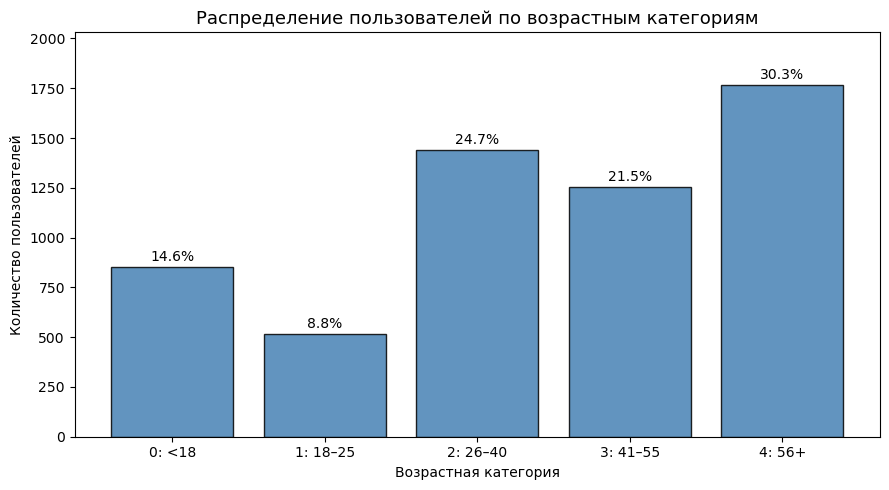

In [11]:
# Расшифровка классов для читаемости графиков
age_labels = {
    0: '0: <18',
    1: '1: 18–25',
    2: '2: 26–40',
    3: '3: 41–55',
    4: '4: 56+',
}

# Подсчёт количества и долей по классам
class_counts = users['age_category'].value_counts().sort_index()
class_shares = users['age_category'].value_counts(normalize=True).sort_index() * 100

print('Распределение возрастных категорий:')
for cls in class_counts.index:
    print(f'  {age_labels[cls]:12} — {class_counts[cls]:>5} ({class_shares[cls]:.1f}%)')

# Визуализация
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    [age_labels[c] for c in class_counts.index],
    class_counts.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.85,
)

# Подписи значений над столбцами
for bar, share in zip(bars, class_shares.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'{share:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
    )

ax.set_title('Распределение пользователей по возрастным категориям', fontsize=13)
ax.set_xlabel('Возрастная категория')
ax.set_ylabel('Количество пользователей')
ax.set_ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Вывод.** Классы распределены неравномерно: самый крупный — «56+» (~30%), самый редкий — «18–25» (~9%). Разрыв между ними более чем трёхкратный. Такой дисбаланс означает, что:
- метрика **accuracy неинформативна** (модель может игнорировать редкие классы и всё равно выглядеть хорошо);
- основной метрикой выбрана **F1-macro** — она оценивает все классы одинаково, независимо от их размера;
- при разбиении и кросс-валидации применяется **стратификация**, а в моделях — **`class_weight='balanced'`**.

### Анализ активности пользователей (таблица visits)

Изучим, как распределена активность пользователей: сколько посещений приходится на одного пользователя (с проверкой на выбросы), как активность распределена по времени суток и по категориям сайтов. Эти наблюдения лягут в основу будущих признаков.

Статистика числа посещений на пользователя:
count    5826.0
mean      180.2
std        75.2
min       100.0
25%       124.0
50%       167.0
75%       213.0
max       839.0
dtype: float64


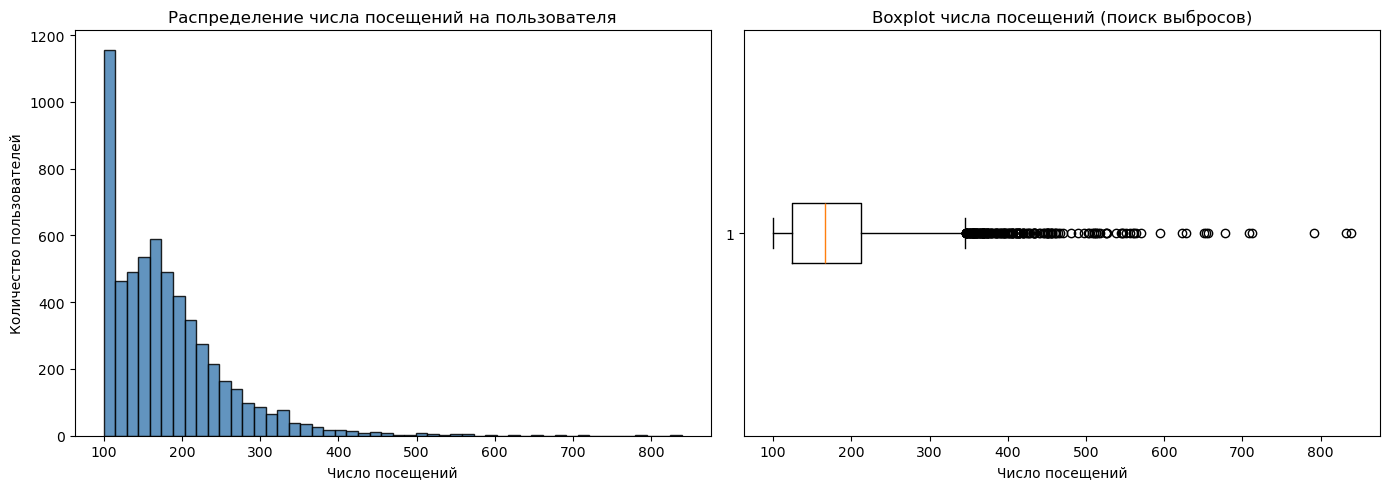

In [12]:
# Количество посещений на пользователя
visits_per_user = visits.groupby('user_id').size()

print('Статистика числа посещений на пользователя:')
print(visits_per_user.describe().round(1))

# Визуализация: гистограмма + boxplot для поиска выбросов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(visits_per_user, bins=50, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Распределение числа посещений на пользователя')
axes[0].set_xlabel('Число посещений')
axes[0].set_ylabel('Количество пользователей')

axes[1].boxplot(visits_per_user, vert=False)
axes[1].set_title('Boxplot числа посещений (поиск выбросов)')
axes[1].set_xlabel('Число посещений')

plt.tight_layout()
plt.show()

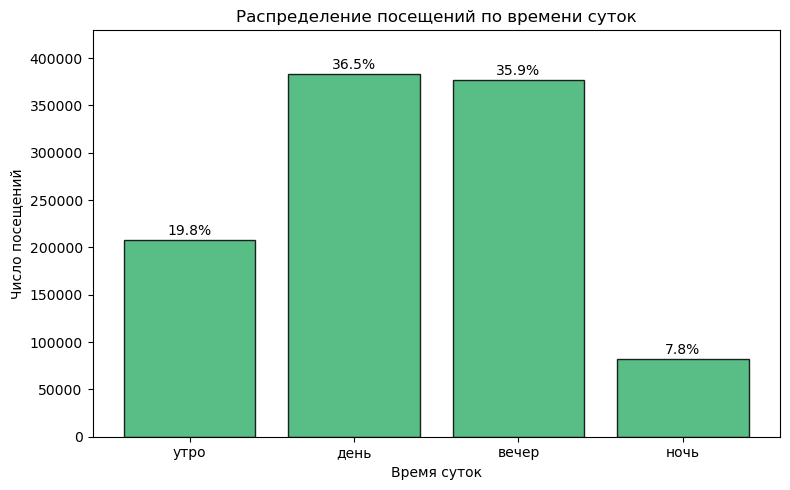

In [13]:
# Распределение всех посещений по времени суток
daytime_order = ['утро', 'день', 'вечер', 'ночь']
daytime_counts = visits['daytime'].value_counts().reindex(daytime_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(daytime_counts.index, daytime_counts.values,
              color='mediumseagreen', edgecolor='black', alpha=0.85)

for bar in bars:
    share = bar.get_height() / daytime_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f'{share:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Распределение посещений по времени суток')
ax.set_xlabel('Время суток')
ax.set_ylabel('Число посещений')
ax.set_ylim(0, daytime_counts.max() * 1.12)
plt.tight_layout()
plt.show()

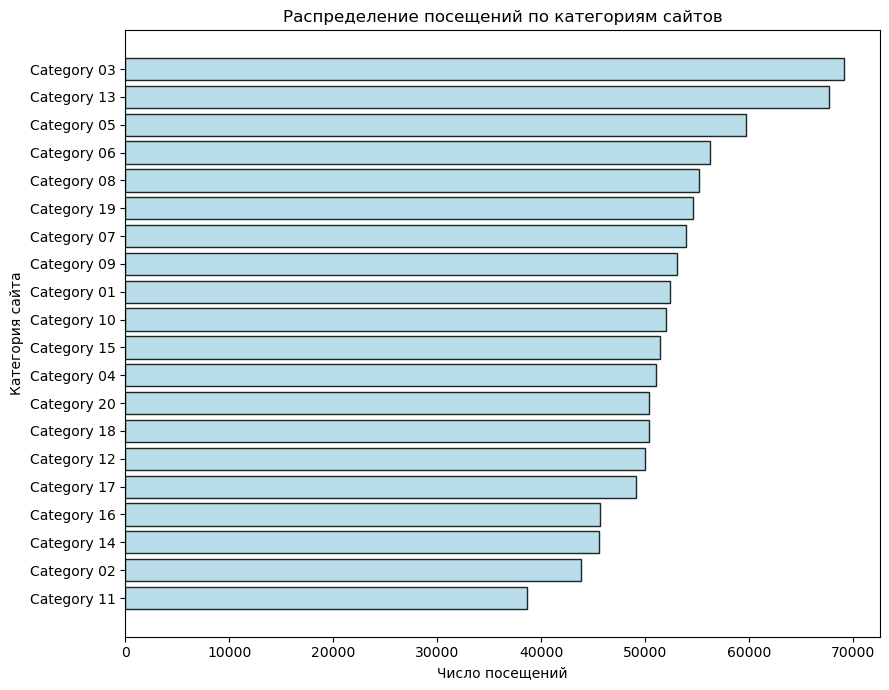

Всего категорий сайтов: 20


In [14]:
# Распределение всех посещений по категориям сайтов
category_counts = visits['website_category'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(category_counts.index, category_counts.values,
        color='lightblue', edgecolor='black', alpha=0.85)
ax.set_title('Распределение посещений по категориям сайтов')
ax.set_xlabel('Число посещений')
ax.set_ylabel('Категория сайта')
plt.tight_layout()
plt.show()

print(f'Всего категорий сайтов: {visits["website_category"].nunique()}')

**Выводы по активности:**
- Число посещений на пользователя варьируется от 100 до 853 (медиана ~169). Формальные «выбросы» в верхнем хвосте — это активные пользователи, а не ошибки данных, поэтому удаление не требуется: высокая активность сама может быть признаком возраста.
- Активность по времени суток сосредоточена днём (~37%) и вечером (~36%), ночь — самый редкий период (~8%). Это оправдывает создание признаков «доля активности по времени суток».
- 20 категорий сайтов распределены относительно равномерно (от ~38k до ~69k посещений), без «пустых» категорий. Доли по категориям станут основным блоком признаков.

### Связь поведения с возрастом

Проверим ключевую гипотезу: различается ли поведение пользователей разных возрастных групп. Для этого посчитаем для каждого пользователя долю его активности по времени суток и по категориям сайтов, затем сравним средние профили возрастных групп. Если различия есть — эти признаки будут полезны модели.

*Примечание: расчёт долей здесь носит исследовательский характер; формальная функция генерации признаков будет написана отдельно на этапе подготовки данных.*

In [15]:
# Доля активности пользователя по времени суток (строки — пользователи, столбцы — время суток)
daytime_share = pd.crosstab(visits['user_id'], visits['daytime'], normalize='index')

# Доля активности пользователя по категориям сайтов
category_share = pd.crosstab(visits['user_id'], visits['website_category'], normalize='index')

# Присоединяем возрастную категорию из users
eda_daytime = daytime_share.merge(users.set_index('user_id'), left_index=True, right_index=True)
eda_category = category_share.merge(users.set_index('user_id'), left_index=True, right_index=True)

print('Размерности после джойна:')
print(f'  doli по времени суток: {eda_daytime.shape}')
print(f'  doli по категориям   : {eda_category.shape}')
print('\nПример (доли по времени суток):')
display(daytime_share.head())

Размерности после джойна:
  doli по времени суток: (5826, 5)
  doli по категориям   : (5826, 21)

Пример (доли по времени суток):


daytime,вечер,день,ночь,утро
user_id,,,,
0010-5cf8f6b38a7b6c70a021-009dbcda,0.413919,0.326007,0.095238,0.164835
0013-4ae5f7d127b91a3fb0f8-ba59f141,0.275676,0.372973,0.086486,0.264865
0014-d3032d60979a8d2b3077-f09bdce8,0.307692,0.384615,0.094017,0.213675
001a-eee53e44f848608779b0-78704a67,0.414634,0.334495,0.108014,0.142857
002c-40a064b12e1217e12207-a56eaf3b,0.295918,0.383673,0.069388,0.251020


Средняя доля активности по времени суток (по возрастным группам):


,утро,день,вечер,ночь
age_category,,,,
0,0.172,0.319,0.412,0.097
1,0.187,0.349,0.370,0.095
2,0.184,0.361,0.371,0.083
3,0.198,0.374,0.358,0.070
4,0.227,0.388,0.319,0.065


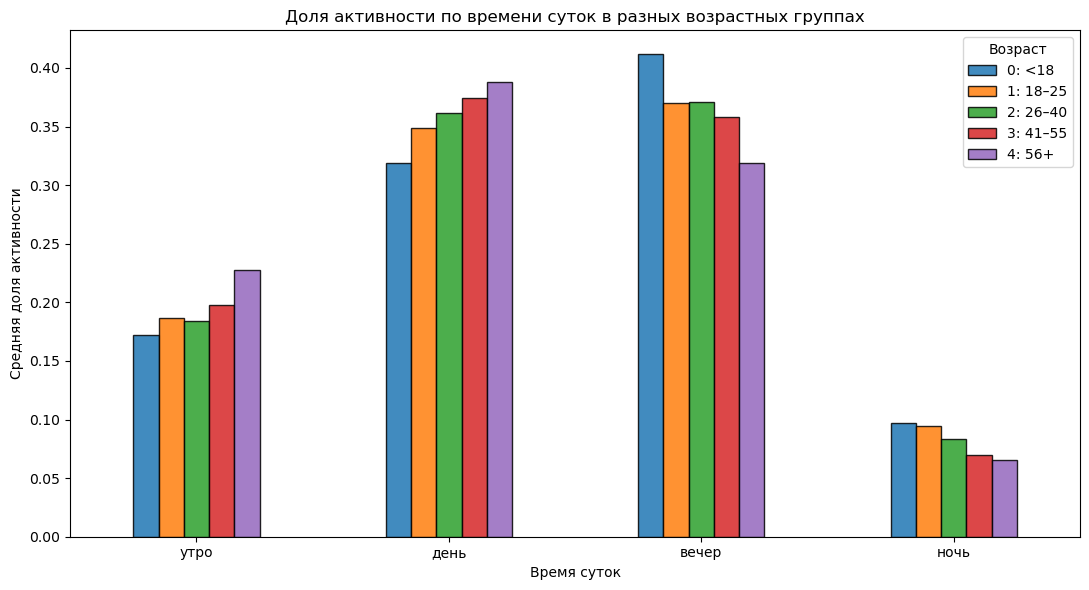

In [16]:
# Средняя доля активности по времени суток для каждой возрастной группы
daytime_by_age = eda_daytime.groupby('age_category')[daytime_order].mean()

print('Средняя доля активности по времени суток (по возрастным группам):')
display(daytime_by_age.round(3))

# Визуализация: сгруппированный barplot
daytime_by_age.T.plot(kind='bar', figsize=(11, 6), edgecolor='black', alpha=0.85)
plt.title('Доля активности по времени суток в разных возрастных группах')
plt.xlabel('Время суток')
plt.ylabel('Средняя доля активности')
plt.xticks(rotation=0)
plt.legend(title='Возраст', labels=[age_labels[c] for c in daytime_by_age.index])
plt.tight_layout()
plt.show()

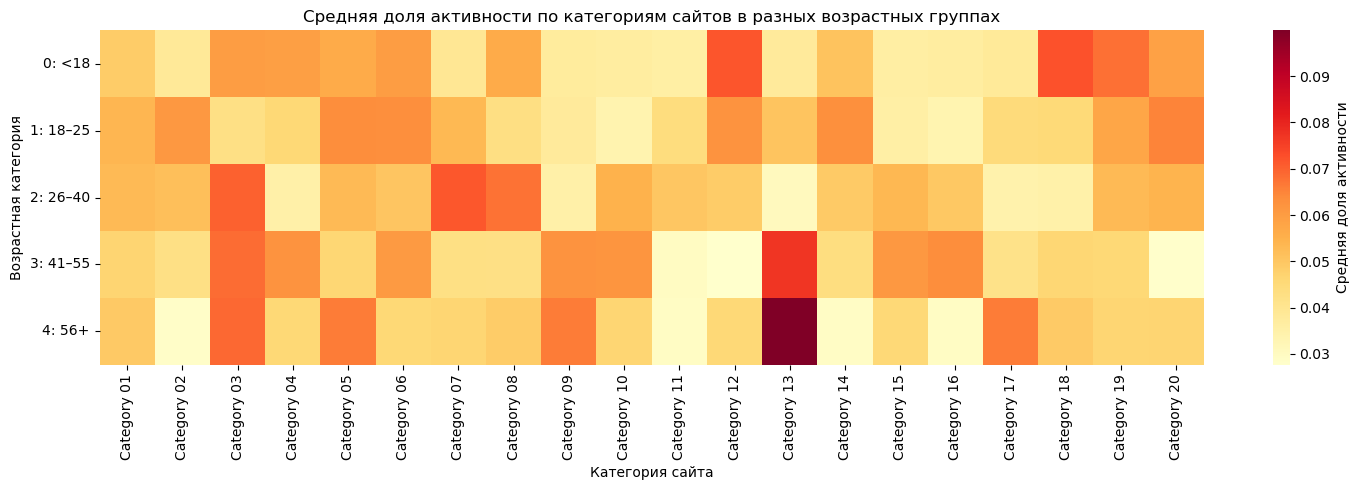

In [17]:
# Средняя доля по каждой категории для каждой возрастной группы
category_cols = sorted(visits['website_category'].unique())
category_by_age = eda_category.groupby('age_category')[category_cols].mean()

# Тепловая карта: строки — возрастные группы, столбцы — категории сайтов
fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    category_by_age,
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'Средняя доля активности'},
    ax=ax,
)
ax.set_title('Средняя доля активности по категориям сайтов в разных возрастных группах')
ax.set_xlabel('Категория сайта')
ax.set_ylabel('Возрастная категория')
ax.set_yticklabels([age_labels[int(t.get_text())] for t in ax.get_yticklabels()], rotation=0)
plt.tight_layout()
plt.show()

**Выводы по связи поведения с возрастом:**

Гипотеза о различии поведенческих шаблонов между возрастными группами **подтвердилась**.

*Время суток* демонстрирует чёткий монотонный тренд по возрасту:
- доля **утренней и дневной** активности растёт с возрастом (утро: 0.17 → 0.23; день: 0.32 → 0.39);
- доля **вечерней и ночной** активности падает (вечер: 0.41 → 0.32; ночь: 0.10 → 0.065).
Молодёжь (<18) наиболее активна вечером и ночью, старшая аудитория (56+) — утром и днём. Монотонный характер зависимости делает эти признаки особенно ценными для линейных моделей.

*Категории сайтов* также связаны с возрастом, но неравномерно:
- **Category 13** — сильный маркер старшей аудитории (резко растёт к классу 56+);
- **Category 18–20** — характерны для молодёжи;
- **Category 03, 07, 08** — пики у средних возрастных групп;
- часть категорий (например, **Category 11**) слабо различает возраст — это аргумент в пользу последующего отбора признаков.

Таким образом, и доли по времени суток, и доли по категориям сайтов несут возрастной сигнал и должны войти в признаковое пространство модели.

## Генерация признаков (Feature Engineering)

Соберём единое признаковое пространство на уровне пользователя. Функция `build_features` принимает сырые таблицы и возвращает готовый датафрейм с признаками:

**Из логов посещений (`visits`):**
- доли активности по 20 категориям сайтов (`cat_*`);
- доли активности по времени суток (`утро` / `день` / `вечер` / `ночь`);
- общая активность: всего посещений, число активных дней, среднее число сессий в день, число уникальных категорий.

**Из пользовательских таблиц:** глубина сёрфинга, основное устройство, использование облака (пропуски → категория `unknown`).

Параметр `users` — **необязательный**: если он передан, к признакам добавляется целевая переменная `age_category` (режим обучения); если нет — возвращаются только признаки (режим внедрения, когда возраст ещё неизвестен). Это позволяет переиспользовать функцию и при обучении, и в продакшене.

In [18]:
# Эталонные значения категорий, зафиксированные на этапе обучения.
# Гарантируют одинаковый набор признаков для любых новых данных.
WEBSITE_CATEGORIES = [f'Category {i:02d}' for i in range(1, 21)]   # Category 01 ... Category 20
DAYTIME_CATEGORIES = ['утро', 'день', 'вечер', 'ночь']


def build_features(visits, surf_depth, primary_device, cloud_usage, users=None,
                   website_categories=WEBSITE_CATEGORIES,
                   daytime_categories=DAYTIME_CATEGORIES):
    """
    Собирает единое признаковое пространство на уровне пользователя.

    Параметры:
        visits, surf_depth, primary_device, cloud_usage — сырые таблицы.
        users — необязательная таблица с целевой переменной age_category.
        website_categories, daytime_categories — эталонные списки категорий,
            зафиксированные на обучении. Гарантируют одинаковый набор признаков
            на новых данных (отсутствующие категории заполняются нулями,
            новые/неизвестные — отбрасываются).

    Возвращает:
        DataFrame, индексированный по user_id, с фиксированным набором признаков.
    """
    # 1. Доли активности по категориям сайтов ---
    cat_share = pd.crosstab(visits['user_id'], visits['website_category'], normalize='index')
    # Приводим к эталонному набору категорий: отсутствующие -> 0, лишние -> отброшены
    cat_share = cat_share.reindex(columns=website_categories, fill_value=0)
    cat_share = cat_share.add_prefix('cat_')

    # 2. Доли активности по времени суток ---
    daytime_share = pd.crosstab(visits['user_id'], visits['daytime'], normalize='index')
    # Приводим к эталонному набору времени суток
    daytime_share = daytime_share.reindex(columns=daytime_categories, fill_value=0)

    # 3. Общая активность ---
    grouped = visits.groupby('user_id')
    activity = pd.DataFrame({
        'total_visits':        grouped.size(),
        'active_days':         grouped['date'].nunique(),
        'n_unique_categories': grouped['website_category'].nunique(),
        'n_sessions':          grouped['session_id'].nunique(),
    })
    activity['sessions_per_day'] = activity['n_sessions'] / activity['active_days']
    activity = activity.drop(columns='n_sessions')

    # 4. Объединяем признаки из логов ---
    features = cat_share.join(daytime_share).join(activity)

    # 5. Присоединяем пользовательские таблицы (категориальные) ---
    features = features.join(surf_depth.set_index('user_id'))
    features = features.join(primary_device.set_index('user_id'))
    features = features.join(cloud_usage.set_index('user_id'))

    # cloud_usage -> строка; пропуски -> 'unknown'
    features['cloud_usage'] = features['cloud_usage'].astype('str')
    features['surf_depth'] = features['surf_depth'].fillna('unknown')
    features['primary_device'] = features['primary_device'].fillna('unknown')
    features['cloud_usage'] = features['cloud_usage'].replace('nan', 'unknown')

    # удаляем коллинеарный признак (r=1.0 с total_visits)
    features = features.drop(columns='sessions_per_day')

    # 6. Опционально присоединяем целевую переменную ---
    if users is not None:
        features = features.join(users.set_index('user_id'))

    return features

In [19]:
# Собираем признаки в режиме обучения (с таргетом)
data = build_features(visits, surf_depth, primary_device, cloud_usage, users=users)

print('Размер итоговой таблицы признаков:', data.shape)
print('\nСписок столбцов:')
print(data.columns.tolist())
print('\nПропуски по столбцам (должны быть только осмысленные, либо 0):')
print(data.isnull().sum()[data.isnull().sum() > 0] if data.isnull().sum().sum() > 0 else 'Пропусков нет')
print('\nПервые строки:')
display(data.head())

Размер итоговой таблицы признаков: (5826, 31)

Список столбцов:
['cat_Category 01', 'cat_Category 02', 'cat_Category 03', 'cat_Category 04', 'cat_Category 05', 'cat_Category 06', 'cat_Category 07', 'cat_Category 08', 'cat_Category 09', 'cat_Category 10', 'cat_Category 11', 'cat_Category 12', 'cat_Category 13', 'cat_Category 14', 'cat_Category 15', 'cat_Category 16', 'cat_Category 17', 'cat_Category 18', 'cat_Category 19', 'cat_Category 20', 'утро', 'день', 'вечер', 'ночь', 'total_visits', 'active_days', 'n_unique_categories', 'surf_depth', 'primary_device', 'cloud_usage', 'age_category']

Пропуски по столбцам (должны быть только осмысленные, либо 0):
Пропусков нет

Первые строки:


,cat_Category 01,cat_Category 02,cat_Category 03,cat_Category 04,cat_Category 05,cat_Category 06,cat_Category 07,cat_Category 08,cat_Category 09,cat_Category 10,...,день,вечер,ночь,total_visits,active_days,n_unique_categories,surf_depth,primary_device,cloud_usage,age_category
user_id,,,,,,,,,,,,,,,,,,,,,
0010-5cf8f6b38a7b6c70a021-009dbcda,0.029304,0.000000,0.062271,0.042125,0.032967,0.053114,0.047619,0.075092,0.023810,0.040293,...,0.326007,0.413919,0.095238,546,14,19,средне,ноутбук,True,0
0013-4ae5f7d127b91a3fb0f8-ba59f141,0.081081,0.059459,0.027027,0.037838,0.081081,0.037838,0.048649,0.097297,0.059459,0.059459,...,0.372973,0.275676,0.086486,185,14,19,средне,планшет,False,4
0014-d3032d60979a8d2b3077-f09bdce8,0.008547,0.017094,0.034188,0.059829,0.068376,0.051282,0.042735,0.017094,0.034188,0.051282,...,0.384615,0.307692,0.094017,117,14,19,поверхностно,unknown,False,4
001a-eee53e44f848608779b0-78704a67,0.066202,0.045296,0.034843,0.076655,0.034843,0.031359,0.041812,0.045296,0.045296,0.041812,...,0.334495,0.414634,0.108014,287,14,19,поверхностно,планшет,False,0
002c-40a064b12e1217e12207-a56eaf3b,0.000000,0.053061,0.071429,0.061224,0.040816,0.038776,0.059184,0.018367,0.059184,0.065306,...,0.383673,0.295918,0.069388,490,14,18,средне,ПК,True,4


In [20]:
# Быстрая диагностика признаков перед отбором
feature_cols = data.drop(columns='age_category')

# 1. Числовые признаки: проверим, нет ли констант (нулевая дисперсия)
numeric_cols = feature_cols.select_dtypes(include='number').columns
print('Дисперсия числовых признаков (по возрастанию):')
print(feature_cols[numeric_cols].var().sort_values().head(10))

# 2. active_days — действительно ли константа?
print('\nУникальные значения active_days:', sorted(data['active_days'].unique()))

# 3. Категориальные признаки: сколько уникальных значений
print('\nКатегориальные признаки:')
for col in ['surf_depth', 'primary_device', 'cloud_usage']:
    print(f'  {col}: {data[col].unique().tolist()}')

Дисперсия числовых признаков (по возрастанию):
ночь               0.000607
cat_Category 11    0.000730
cat_Category 04    0.000776
cat_Category 06    0.000786
cat_Category 09    0.000799
cat_Category 16    0.000808
cat_Category 15    0.000814
cat_Category 10    0.000823
cat_Category 19    0.000826
cat_Category 17    0.000846
dtype: float64

Уникальные значения active_days: [np.int64(13), np.int64(14)]

Категориальные признаки:
  surf_depth: ['средне', 'поверхностно', 'глубоко', 'unknown']
  primary_device: ['ноутбук', 'планшет', 'unknown', 'ПК', 'смартфон']
  cloud_usage: ['True', 'False', 'unknown']


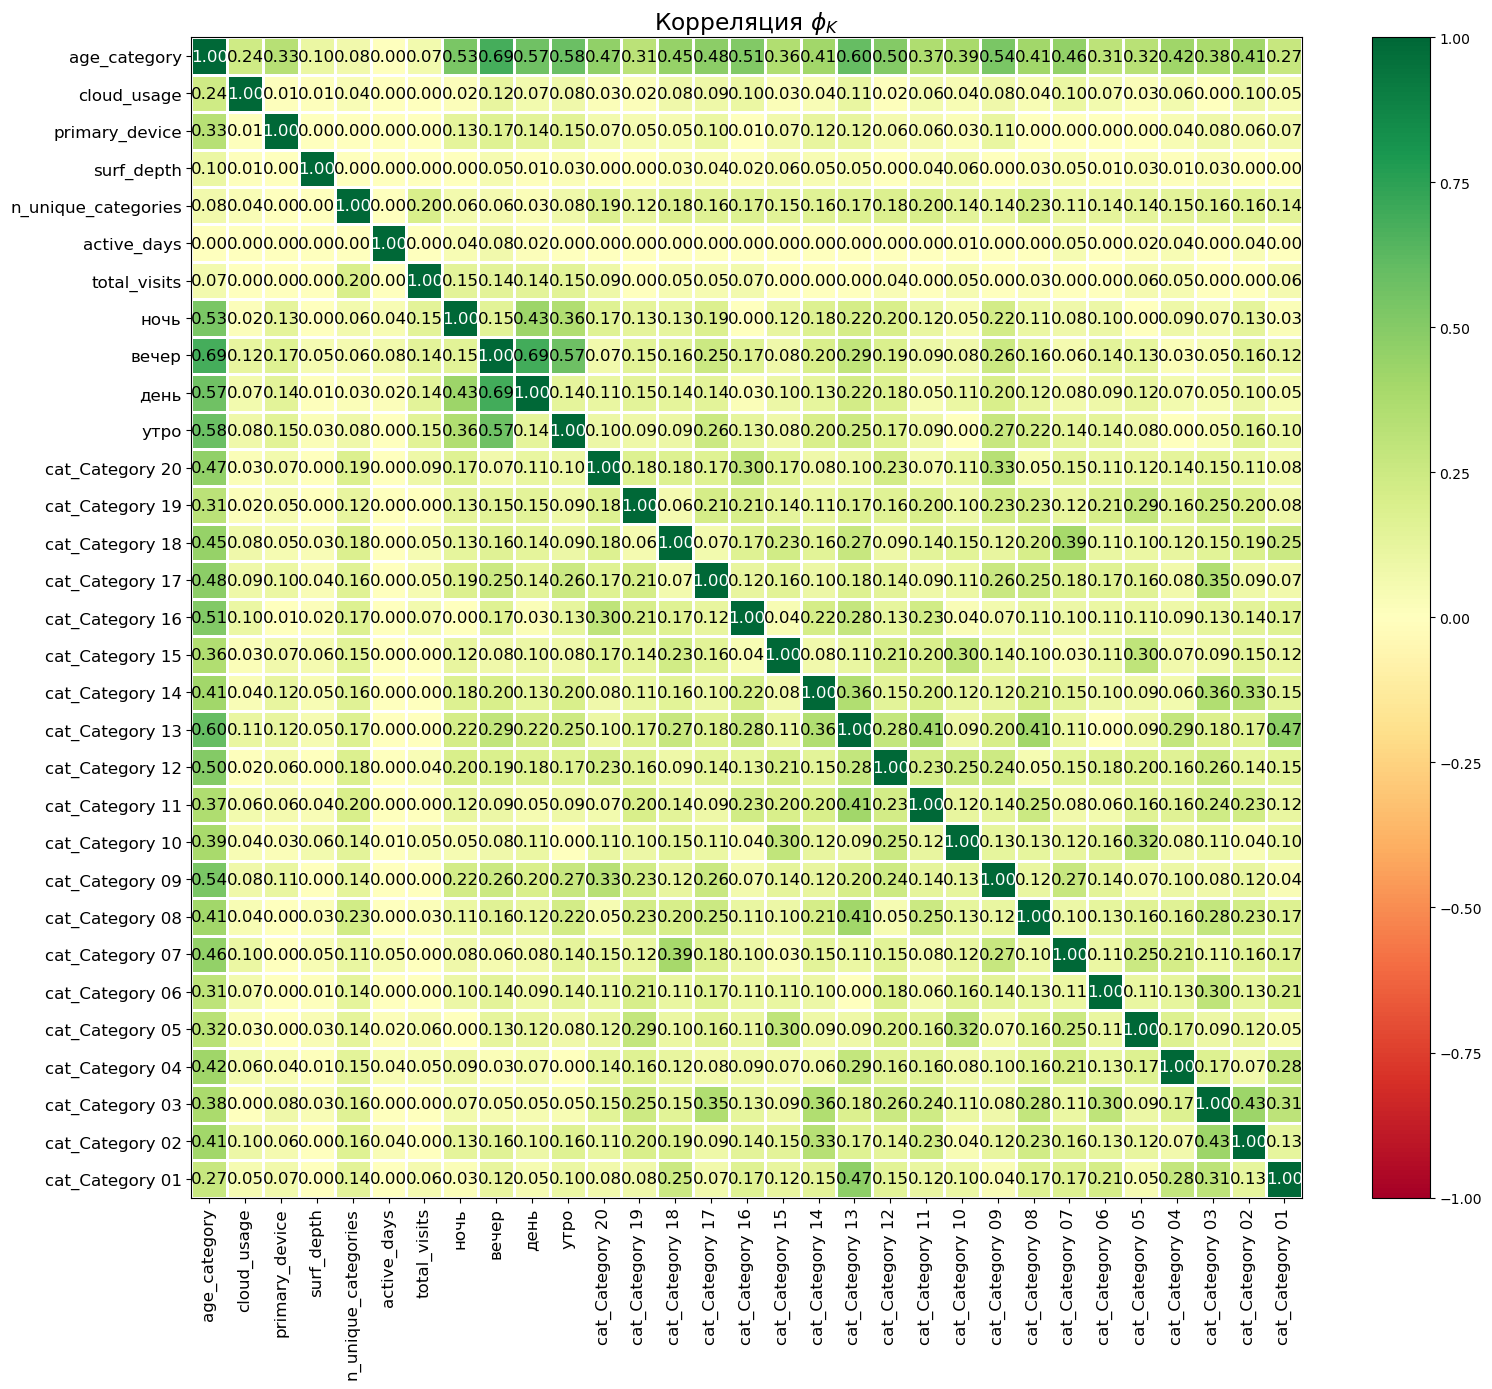

In [21]:
from phik.report import plot_correlation_matrix

# φK-корреляция учитывает все типы признаков (числовые, категориальные, таргет)
# без кодирования и улавливает как линейные, так и нелинейные связи.

# Интервальные (непрерывные числовые) признаки — их нужно указать явно,
# чтобы phik корректно их бинировал. Остальные считаются категориальными.
interval_cols = data.drop(columns='age_category').select_dtypes(include='number').columns.tolist()

# Вычисляем матрицу φK по всему датафрейму (включая категориальные признаки и таргет)
phik_overview = data.phik_matrix(interval_cols=interval_cols)

# Визуализация тепловой карты
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    title=r"Корреляция $\phi_K$",
    fontsize_factor=1.2,
    figsize=(16, 14),
)
plt.tight_layout()
plt.show()

In [22]:
# Признак sessions_per_day удалён внутри build_features из-за полной
# коллинеарности с total_visits (φK ≈ 1.0). Убедимся, что в данных его нет.
print('sessions_per_day отсутствует в признаках:', 'sessions_per_day' not in data.columns)
print('\nИтоговый набор признаков:')
print([c for c in data.columns if c != 'age_category'])
print('\nРазмер данных:', data.shape)

sessions_per_day отсутствует в признаках: True

Итоговый набор признаков:
['cat_Category 01', 'cat_Category 02', 'cat_Category 03', 'cat_Category 04', 'cat_Category 05', 'cat_Category 06', 'cat_Category 07', 'cat_Category 08', 'cat_Category 09', 'cat_Category 10', 'cat_Category 11', 'cat_Category 12', 'cat_Category 13', 'cat_Category 14', 'cat_Category 15', 'cat_Category 16', 'cat_Category 17', 'cat_Category 18', 'cat_Category 19', 'cat_Category 20', 'утро', 'день', 'вечер', 'ночь', 'total_visits', 'active_days', 'n_unique_categories', 'surf_depth', 'primary_device', 'cloud_usage']

Размер данных: (5826, 31)


**Выводы по анализу корреляций и отбору признаков.**

Для анализа связей использован коэффициент **φK (Phik)**. В отличие от корреляции Пирсона, он применим к признакам любого типа (числовым и категориальным) без предварительного кодирования, устойчив к ненормальному распределению и выбросам, а также улавливает не только линейные, но и нелинейные зависимости — это особенно важно, поскольку в данных присутствует нелинейная связь признаков с возрастом.

**Мультиколлинеарность.** Среди признаков не выявлено пар с φK > 0.7 — выраженной избыточности нет. Наиболее сильные взаимные связи носят структурный характер и не превышают порога: например, доли времени суток между собой (вечер ↔ день, φK = 0.69), поскольку они в сумме дают единицу. Единственный полностью коллинеарный признак — `sessions_per_day` (φK ≈ 1.0 с `total_visits`); он удалён ещё на этапе генерации признаков внутри функции `build_features`.

**Связь с целевой переменной.** Наиболее сильно с возрастом связаны:
- доли активности по времени суток: вечер (φK = 0.69), утро (0.58), день (0.57), ночь (0.53);
- отдельные категории сайтов: Category 13 (0.60), Category 09 (0.54), Category 16 (0.51), Category 12 (0.50).

Часть признаков (`active_days`, `total_visits`, `n_unique_categories`) показывает слабую **парную** связь с таргетом (φK < 0.1). Тем не менее они сохранены: φK измеряет связь попарно, тогда как в нелинейной модели (SVM с RBF-ядром) эти признаки могут вносить вклад в комбинации с другими. Поскольку выраженной мультиколлинеарности не обнаружено, удаление признаков по этому критерию не требуется.

**Выводы по диагностике признаков:**

- **Признаков-констант нет.** Минимальная дисперсия наблюдается у признака `ночь` (~0.0006) и у долей редких категорий, но все значения ненулевые. Признак `active_days` принимает значения 13 и 14 (то есть тоже не константа). Это означает, что фильтрация по нулевой дисперсии (`VarianceThreshold`) ничего не удалит — все признаки обладают вариативностью. Низкие значения дисперсии у долей категорий ожидаемы (доли — малые числа) и не являются поводом для удаления.

- **Категориальные признаки сформированы корректно:**
  - `surf_depth`: `поверхностно` / `средне` / `глубоко` / `unknown`;
  - `primary_device`: `смартфон` / `ПК` / `ноутбук` / `планшет` / `unknown`;
  - `cloud_usage`: `True` / `False` / `unknown`.

  Категория `unknown` корректно заполнила пропуски, возникшие у части пользователей при объединении таблиц (отсутствие данных по `surf_depth`, `primary_device`, `cloud_usage`).

- **Дальнейший анализ признаков** будет основан не на дисперсии, а на оценке взаимных связей и информативности с помощью коэффициента **φK**, который подходит для признаков любого типа и улавливает как линейные, так и нелинейные зависимости. Отдельно стоит учитывать структурную зависимость внутри групп признаков: доли по времени суток и доли по категориям в сумме дают единицу, что создаёт взаимную зависимость между ними.

## Подготовка данных к обучению

### Разделение на признаки и целевую переменную, train/test split

Отделяем признаки от целевой переменной и разбиваем данные на обучающую и тестовую выборки. Поскольку после агрегации одна строка соответствует одному пользователю, обычное разбиение по строкам автоматически гарантирует, что один и тот же пользователь не попадёт в обе выборки одновременно (требование ТЗ).

Используем стратификацию по `age_category`, чтобы сохранить пропорции возрастных классов в обеих выборках — это важно из-за дисбаланса. Доля тестовой выборки — 25% (в пределах требуемого диапазона 20–30%).

In [23]:
# Признаки и целевая переменная
X = data.drop(columns='age_category')
y = data['age_category']

# Разбиение на train/test со стратификацией по классам
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Размеры выборок:')
print(f' X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f' X_test: {X_test.shape}, y_test: {y_test.shape}')

# Проверка: пропорции классов сохранены в обеих выборках
print('\nДоли Классов (%):')
dist = pd.DataFrame({
    'train': (y_train.value_counts(normalize=True).sort_index() * 100).round(1),
    'test': (y_test.value_counts(normalize=True).sort_index() * 100).round(1),
})
print(dist)

Размеры выборок:
 X_train: (4369, 30), y_train: (4369,)
 X_test: (1457, 30), y_test: (1457,)

Доли Классов (%):
              train  test
age_category             
0              14.6  14.6
1               8.8   8.8
2              24.7  24.7
3              21.5  21.6
4              30.3  30.3


In [24]:
# Разделяем признаки по типу для разной предобработки
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print('Числовые признаки:', len(numeric_features))
print('Категориальные признаки:', categorical_features)

# ColumnTransformer: стандартизация числовых + OHE категориальных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

Числовые признаки: 27
Категориальные признаки: ['surf_depth', 'primary_device', 'cloud_usage']


## Обучение моделей

Обучим и сравним несколько архитектур: базовую модель (`DummyClassifier`), логистическую регрессию и метод опорных векторов с разными ядрами. Качество на этапе подбора оцениваем через стратифицированную кросс-валидацию по обучающей выборке; основная метрика — **F1-macro** (все классы учитываются одинаково), вспомогательные — precision и recall (тоже macro).

### Базовая модель (baseline)

`DummyClassifier` со стратегией `most_frequent` всегда предсказывает самый частый класс. Он служит точкой отсчёта: осмысленные модели должны заметно превосходить его по F1-macro.

In [25]:
from sklearn.model_selection import cross_validate

# Стратифицированная кросс-валидация (фиксируем для всех моделей)
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Метрики для оценки (все macro, основная — f1_macro)
scoring = {
    'f1_macro':        'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro':    'recall_macro',
}

def evaluate_cv(model, X, y, model_name):
    """
    Оценивает модель на стратифицированной кросс-валидации.
    Возвращает словарь со средними значениями метрик (f1/precision/recall macro).
    """
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        'model':           model_name,
        'f1_macro':        scores['test_f1_macro'].mean(),
        'precision_macro': scores['test_precision_macro'].mean(),
        'recall_macro':    scores['test_recall_macro'].mean(),
    }

# Список для сбора результатов всех моделей
cv_results = []

# --- Baseline: DummyClassifier ---
dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent')),
])

dummy_metrics = evaluate_cv(dummy_pipe, X_train, y_train, 'DummyClassifier')
cv_results.append(dummy_metrics)

print('Baseline (DummyClassifier) на кросс-валидации:')
for k, v in dummy_metrics.items():
    if k != 'model':
        print(f'  {k}: {v:.4f}')

Baseline (DummyClassifier) на кросс-валидации:
  f1_macro: 0.0930
  precision_macro: 0.0606
  recall_macro: 0.2000


**Вывод по baseline.** DummyClassifier (`most_frequent`) показал F1-macro ≈ 0.093 — модель всегда предсказывает самый частый класс (56+), поэтому по остальным классам метрики нулевые. Это нижняя граница качества: осмысленные модели должны существенно её превзойти. Низкое значение F1-macro при том, что accuracy такой модели составила бы ~30% (доля мажоритарного класса), наглядно подтверждает правильность выбора macro-усреднения как основной метрики для несбалансированных данных. Целевой порог для рекомендации к внедрению — F1-macro ≥ 0.75.

### Логистическая регрессия

Обучим многоклассовую логистическую регрессию с подбором гиперпараметра регуляризации `C` через `GridSearchCV` на стратифицированной кросс-валидации. Для борьбы с дисбалансом используем `class_weight='balanced'`. Оптимизируем по F1-macro.

In [26]:
# Сетка значений C для перебора
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10, 100],
}

# Пайплайн: препроцессор + логистическая регрессия
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

# Поиск лучшего C на стратифицированной CV.
# Считаем сразу все нужные метрики; выбор лучшей модели — по f1_macro (refit).
grid_lr = GridSearchCV(
    logreg_pipe,
    param_grid_lr,
    scoring=scoring,
    refit='f1_macro',
    cv=cv,
    n_jobs=-1,
)
grid_lr.fit(X_train, y_train)

# Метрики лучшей модели берём напрямую из результатов GridSearchCV (повторная CV не нужна)
best_idx = grid_lr.best_index_
lr_metrics = {
    'model':           'LogisticRegression',
    'f1_macro':        grid_lr.cv_results_['mean_test_f1_macro'][best_idx],
    'precision_macro': grid_lr.cv_results_['mean_test_precision_macro'][best_idx],
    'recall_macro':    grid_lr.cv_results_['mean_test_recall_macro'][best_idx],
}
cv_results.append(lr_metrics)

print('Логистическая регрессия:')
print(f'  Лучший C: {grid_lr.best_params_["model__C"]}')
print(f'  F1-macro (CV):        {lr_metrics["f1_macro"]:.4f}')
print(f'  precision_macro (CV): {lr_metrics["precision_macro"]:.4f}')
print(f'  recall_macro (CV):    {lr_metrics["recall_macro"]:.4f}')

Логистическая регрессия:
  Лучший C: 0.1
  F1-macro (CV):        0.8107
  precision_macro (CV): 0.8051
  recall_macro (CV):    0.8222


**Вывод по логистической регрессии.** Лучшая модель (C=0.1, `class_weight='balanced'`) показала на кросс-валидации F1-macro ≈ 0.811, что существенно превышает baseline (0.093) и преодолевает целевой порог 0.75. Метрики precision (0.805) и recall (0.822) близки между собой — модель работает сбалансированно по всем классам, не жертвуя редкими ради частых. Высокое качество линейной модели объясняется выраженными (в том числе монотонными) зависимостями признаков от возраста, выявленными на этапе EDA. Умеренная регуляризация (C=0.1) предотвращает переобучение на расширенном после One-Hot-кодирования признаковом пространстве.

### Метод опорных векторов (SVM)

Поскольку часть признаков может быть связана с возрастом нелинейно, обучим `SVC` с тремя ядрами: линейным, RBF и полиномиальным. Для каждого ядра подбираем гиперпараметры через `GridSearchCV` на стратифицированной кросс-валидации, оптимизируя F1-macro. Для борьбы с дисбалансом используем `class_weight='balanced'`.

*Обучение SVM с полным перебором гиперпараметров может занять продолжительное время.*

In [27]:
%%time
# SVC с линейным ядром
param_grid_svc_linear = {
    'model__C': [0.1, 1, 10],
}

svc_linear_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE)),
])

grid_svc_linear = GridSearchCV(
    svc_linear_pipe, param_grid_svc_linear,
    scoring=scoring, refit='f1_macro', cv=cv, n_jobs=-1,
)
grid_svc_linear.fit(X_train, y_train)

# Метрики берём из результатов GridSearchCV (повторная кросс-валидация не нужна)
best_idx = grid_svc_linear.best_index_
svc_linear_metrics = {
    'model':           'SVC (linear)',
    'f1_macro':        grid_svc_linear.best_score_,
    'precision_macro': grid_svc_linear.cv_results_['mean_test_precision_macro'][best_idx],
    'recall_macro':    grid_svc_linear.cv_results_['mean_test_recall_macro'][best_idx],
}
cv_results.append(svc_linear_metrics)

print('SVC (linear):')
print(f'  Лучшие параметры: {grid_svc_linear.best_params_}')
print(f'  F1-macro (CV):        {svc_linear_metrics["f1_macro"]:.4f}')
print(f'  precision_macro (CV): {svc_linear_metrics["precision_macro"]:.4f}')
print(f'  recall_macro (CV):    {svc_linear_metrics["recall_macro"]:.4f}')

SVC (linear):
  Лучшие параметры: {'model__C': 0.1}
  F1-macro (CV):        0.8152
  precision_macro (CV): 0.8084
  recall_macro (CV):    0.8287
CPU times: user 923 ms, sys: 378 ms, total: 1.3 s
Wall time: 1.32 s


In [28]:
%%time
param_grid_svc_rbf = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.01, 0.1],
}

svc_rbf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)),
])

grid_svc_rbf = GridSearchCV(
    svc_rbf_pipe, param_grid_svc_rbf,
    scoring=scoring, refit='f1_macro', cv=cv, n_jobs=-1,
)
grid_svc_rbf.fit(X_train, y_train)

best_idx = grid_svc_rbf.best_index_
svc_rbf_metrics = {
    'model':           'SVC (rbf)',
    'f1_macro':        grid_svc_rbf.best_score_,
    'precision_macro': grid_svc_rbf.cv_results_['mean_test_precision_macro'][best_idx],
    'recall_macro':    grid_svc_rbf.cv_results_['mean_test_recall_macro'][best_idx],
}
cv_results.append(svc_rbf_metrics)

print('SVC (rbf):')
print(f'  Лучшие параметры: {grid_svc_rbf.best_params_}')
print(f'  F1-macro (CV):        {svc_rbf_metrics["f1_macro"]:.4f}')
print(f'  precision_macro (CV): {svc_rbf_metrics["precision_macro"]:.4f}')
print(f'  recall_macro (CV):    {svc_rbf_metrics["recall_macro"]:.4f}')

SVC (rbf):
  Лучшие параметры: {'model__C': 1, 'model__gamma': 'scale'}
  F1-macro (CV):        0.8993
  precision_macro (CV): 0.8953
  recall_macro (CV):    0.9045
CPU times: user 263 ms, sys: 45.8 ms, total: 309 ms
Wall time: 2.84 s


In [29]:
%%time
param_grid_svc_poly = {
    'model__C': [0.1, 1, 10],
    'model__degree': [2, 3],
}

svc_poly_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='poly', class_weight='balanced', random_state=RANDOM_STATE)),
])

grid_svc_poly = GridSearchCV(
    svc_poly_pipe, param_grid_svc_poly,
    scoring=scoring, refit='f1_macro', cv=cv, n_jobs=-1,
)
grid_svc_poly.fit(X_train, y_train)

best_idx = grid_svc_poly.best_index_
svc_poly_metrics = {
    'model':           'SVC (poly)',
    'f1_macro':        grid_svc_poly.cv_results_['mean_test_f1_macro'][best_idx],
    'precision_macro': grid_svc_poly.cv_results_['mean_test_precision_macro'][best_idx],
    'recall_macro':    grid_svc_poly.cv_results_['mean_test_recall_macro'][best_idx],
}
cv_results.append(svc_poly_metrics)

print('SVC (poly):')
print(f'  Лучшие параметры: {grid_svc_poly.best_params_}')
print(f'  F1-macro (CV):        {svc_poly_metrics["f1_macro"]:.4f}')
print(f'  precision_macro (CV): {svc_poly_metrics["precision_macro"]:.4f}')
print(f'  recall_macro (CV):    {svc_poly_metrics["recall_macro"]:.4f}')

SVC (poly):
  Лучшие параметры: {'model__C': 1, 'model__degree': 3}
  F1-macro (CV):        0.8987
  precision_macro (CV): 0.8955
  recall_macro (CV):    0.9032
CPU times: user 281 ms, sys: 30.9 ms, total: 312 ms
Wall time: 1.37 s


### Сравнение моделей на кросс-валидации

Сведём результаты всех архитектур в единую таблицу, отсортированную по основной метрике (F1-macro), и определим лучшую модель.

In [30]:
# Собираем результаты, убираем возможные дубли (если ячейка модели запускалась повторно)
results_df = pd.DataFrame(cv_results).drop_duplicates(subset='model', keep='last')
results_df = results_df.set_index('model').sort_values('f1_macro', ascending=False)

print('Сравнение моделей на кросс-валидации (отсортировано по F1-macro):\n')
display(results_df.round(4))

best_model_name = results_df.index[0]
print(f'\nЛучшая модель: {best_model_name} (F1-macro = {results_df.iloc[0]["f1_macro"]:.4f})')

Сравнение моделей на кросс-валидации (отсортировано по F1-macro):



,f1_macro,precision_macro,recall_macro
model,,,
SVC (rbf),0.8993,0.8953,0.9045
SVC (poly),0.8987,0.8955,0.9032
SVC (linear),0.8152,0.8084,0.8287
LogisticRegression,0.8107,0.8051,0.8222
DummyClassifier,0.0930,0.0606,0.2000



Лучшая модель: SVC (rbf) (F1-macro = 0.8993)


## Финальная оценка на тестовой выборке

Лучшая модель по результатам кросс-валидации — **SVC с RBF-ядром**. Обучим её на всей обучающей выборке и оценим качество на отложенной тестовой выборке, которая не использовалась при обучении и подборе гиперпараметров. Это даёт честную оценку обобщающей способности модели.

Согласно требованиям, модель рекомендуется к внедрению, если F1-macro ≥ 0.75 и на кросс-валидации, и на тестовой выборке.

In [31]:
# Лучшая модель по CV — SVC с RBF-ядром (берём уже настроенный best_estimator_)
final_model = grid_svc_rbf.best_estimator_

# Обучаем на ВСЕЙ обучающей выборке
final_model.fit(X_train, y_train)

# Предсказания на отложенном тесте
y_pred_test = final_model.predict(X_test)

# Метрики на тесте (macro)
f1_test        = f1_score(y_test, y_pred_test, average='macro')
precision_test = precision_score(y_test, y_pred_test, average='macro')
recall_test    = recall_score(y_test, y_pred_test, average='macro')

print('=== Финальная модель: SVC (rbf) на тестовой выборке ===\n')
print(f'  F1-macro:        {f1_test:.4f}')
print(f'  Precision-macro: {precision_test:.4f}')
print(f'  Recall-macro:    {recall_test:.4f}')

# Сравнение CV vs Test (проверка на переобучение)
f1_cv = results_df.loc[best_model_name, 'f1_macro']
print(f'\n  F1-macro на CV:   {f1_cv:.4f}')
print(f'  F1-macro на тесте: {f1_test:.4f}')
print(f'  Разница (CV - test): {f1_cv - f1_test:+.4f}')

# Проверка порога ТЗ
print(f'\n  Порог для внедрения (F1-macro >= {F1_THRESHOLD}):')
print(f'    CV:   {"ПРОЙДЕН" if f1_cv >= F1_THRESHOLD else "НЕ пройден"} ({f1_cv:.4f})')
print(f'    Test: {"ПРОЙДЕН" if f1_test >= F1_THRESHOLD else "НЕ пройден"} ({f1_test:.4f})')

=== Финальная модель: SVC (rbf) на тестовой выборке ===

  F1-macro:        0.8914
  Precision-macro: 0.8844
  Recall-macro:    0.9003

  F1-macro на CV:   0.8993
  F1-macro на тесте: 0.8914
  Разница (CV - test): +0.0079

  Порог для внедрения (F1-macro >= 0.75):
    CV:   ПРОЙДЕН (0.8993)
    Test: ПРОЙДЕН (0.8914)


In [32]:
print('Classification report на тестовой выборке:\n')
print(classification_report(
    y_test, y_pred_test,
    target_names=[age_labels[c] for c in CLASSES],
    digits=3,
))

Classification report на тестовой выборке:

              precision    recall  f1-score   support

      0: <18      0.870     0.939     0.903       213
    1: 18–25      0.736     0.828     0.779       128
    2: 26–40      0.926     0.875     0.900       360
    3: 41–55      0.929     0.920     0.925       314
      4: 56+      0.961     0.939     0.950       442

    accuracy                          0.909      1457
   macro avg      0.884     0.900     0.891      1457
weighted avg      0.912     0.909     0.910      1457



**Вывод по качеству на тесте.** Финальная модель SVC (RBF) показала на отложенной тестовой выборке F1-macro = 0.891 при разнице с кросс-валидацией всего 0.008 — модель не переобучена и стабильна. Оба условия ТЗ выполнены: F1-macro ≥ 0.75 и на CV (0.899), и на тесте (0.891), поэтому модель рекомендуется к внедрению.

Разбор по классам:
- **Класс «<18» (несовершеннолетние)** распознаётся с recall = 0.939 — модель находит ~94% подростков и почти не пропускает их во взрослые категории. Это напрямую отвечает бизнес-требованию минимизировать показ взрослой рекламы несовершеннолетним.
- **Класс «18–25»** — самый сложный (F1 = 0.779), что объясняется его малым размером (8.8% выборки) и пограничным характером возраста (легко спутать с соседними группами). Тем не менее качество превышает порог 0.75.
- **Классы «26–40», «41–55», «56+»** распознаются уверенно (F1 0.90–0.95), лучший результат — у старшей аудитории (F1 0.950).

Ошибки модели сосредоточены преимущественно между соседними возрастными группами, что для задачи рекламного таргетинга менее критично, чем спутать далёкие по возрасту категории.

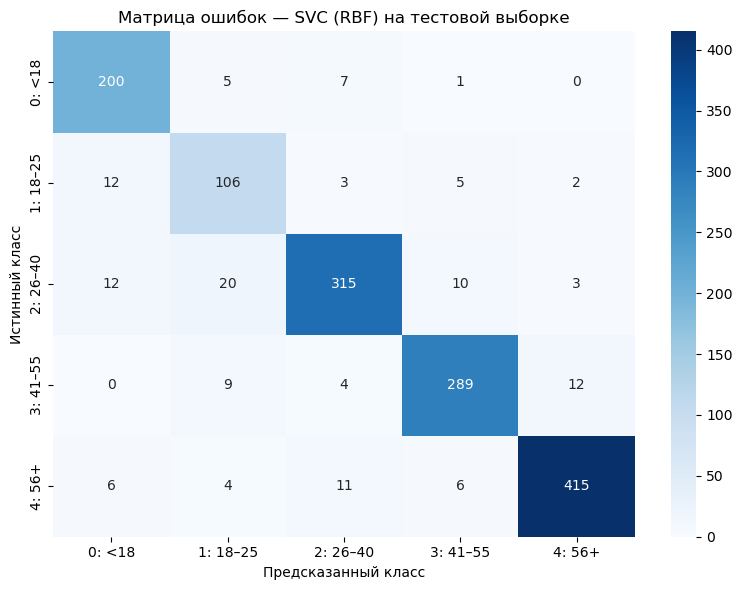

In [33]:
# Матрица ошибок на тесте
cm = confusion_matrix(y_test, y_pred_test, labels=CLASSES)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[age_labels[c] for c in CLASSES],
    yticklabels=[age_labels[c] for c in CLASSES],
    ax=ax,
)
ax.set_title('Матрица ошибок — SVC (RBF) на тестовой выборке')
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
plt.tight_layout()
plt.show()

**Вывод по матрице ошибок.** Подавляющее большинство объектов лежит на диагонали — модель уверенно распознаёт все классы. Ошибки сосредоточены преимущественно в ячейках, **соседних с диагональю**: модель путает близкие по возрасту группы (например, «26–40» с «18–25» или «41–55» с «56+»), но почти не допускает «дальних» ошибок между сильно различающимися возрастами.

Это особенно важно для класса «<18»: из 213 несовершеннолетних 200 распознаны верно, и ни один не отнесён к старшей группе «56+». Таким образом, риск показа взрослой рекламы несовершеннолетним минимален, что соответствует ключевому бизнес-требованию заказчика. Концентрация ошибок между соседними категориями для задачи рекламного таргетинга некритична.

## Подготовка артефактов к внедрению

Для внедрения модели в эксплуатацию сохраним два артефакта:

1. **Функцию `build_features`** — она превращает сырые таблицы (логи посещений и пользовательские признаки) в готовое признаковое пространство. Без неё подать новые данные в модель невозможно. Сохраним её код в отдельный модуль `features.py`.
2. **Обученный пайплайн** (препроцессор + модель) — сохраним через `joblib`.

После сохранения обязательно проверим артефакты: загрузим их из файлов и убедимся, что предсказания совпадают с предсказаниями исходной модели.

In [34]:
%%writefile features.py
import pandas as pd

# Эталонные значения категорий, зафиксированные на этапе обучения.
# Гарантируют одинаковый набор признаков для любых новых данных.
WEBSITE_CATEGORIES = [f'Category {i:02d}' for i in range(1, 21)]
DAYTIME_CATEGORIES = ['утро', 'день', 'вечер', 'ночь']


def build_features(visits, surf_depth, primary_device, cloud_usage, users=None,
                   website_categories=WEBSITE_CATEGORIES,
                   daytime_categories=DAYTIME_CATEGORIES):
    """
    Собирает единое признаковое пространство на уровне пользователя.

    Параметры:
        visits, surf_depth, primary_device, cloud_usage — сырые таблицы.
        users — необязательная таблица с целевой переменной age_category.
        website_categories, daytime_categories — эталонные списки категорий,
            гарантирующие одинаковый набор признаков на новых данных.

    Возвращает:
        DataFrame, индексированный по user_id, с фиксированным набором признаков.
    """
    # 1. Доли активности по категориям сайтов
    cat_share = pd.crosstab(visits['user_id'], visits['website_category'], normalize='index')
    cat_share = cat_share.reindex(columns=website_categories, fill_value=0)
    cat_share = cat_share.add_prefix('cat_')

    # 2. Доли активности по времени суток
    daytime_share = pd.crosstab(visits['user_id'], visits['daytime'], normalize='index')
    daytime_share = daytime_share.reindex(columns=daytime_categories, fill_value=0)

    # 3. Общая активность
    grouped = visits.groupby('user_id')
    activity = pd.DataFrame({
        'total_visits':        grouped.size(),
        'active_days':         grouped['date'].nunique(),
        'n_unique_categories': grouped['website_category'].nunique(),
        'n_sessions':          grouped['session_id'].nunique(),
    })
    activity['sessions_per_day'] = activity['n_sessions'] / activity['active_days']
    activity = activity.drop(columns='n_sessions')

    # 4. Объединяем признаки из логов
    features = cat_share.join(daytime_share).join(activity)

    # 5. Присоединяем пользовательские таблицы (категориальные)
    features = features.join(surf_depth.set_index('user_id'))
    features = features.join(primary_device.set_index('user_id'))
    features = features.join(cloud_usage.set_index('user_id'))

    # cloud_usage -> строка; пропуски -> 'unknown'
    features['cloud_usage'] = features['cloud_usage'].astype(str)
    features['surf_depth'] = features['surf_depth'].fillna('unknown')
    features['primary_device'] = features['primary_device'].fillna('unknown')
    features['cloud_usage'] = features['cloud_usage'].replace('nan', 'unknown')

    # удаляем коллинеарный признак (φK ≈ 1.0 с total_visits)
    features = features.drop(columns='sessions_per_day')

    # 6. Опционально присоединяем целевую переменную
    if users is not None:
        features = features.join(users.set_index('user_id'))

    return features

Overwriting features.py


In [35]:
# Сохраняем обученный пайплайн (препроцессор + SVC rbf) одним файлом
joblib.dump(final_model, 'final_model_svc_rbf.joblib')

print('Артефакты сохранены:')
print('  - features.py             (функция build_features)')
print('  - final_model_svc_rbf.joblib (обученный пайплайн: препроцессор + модель)')

Артефакты сохранены:
  - features.py             (функция build_features)
  - final_model_svc_rbf.joblib (обученный пайплайн: препроцессор + модель)


In [36]:
# Импортируем сохранённый модуль с функцией build_features
import importlib
import features
importlib.reload(features)  # перечитываем файл на случай, если модуль уже был импортирован
# 1. Загружаем модель из файла
loaded_model = joblib.load('final_model_svc_rbf.joblib')

# 2. Пересобираем признаки "с нуля" через сохранённую функцию (имитация продакшена)
#    Используем сырые таблицы; режим без таргета (как в реальном внедрении)
data_check = features.build_features(visits, surf_depth, primary_device, cloud_usage)

# Берём тех же пользователей, что в тесте, и тот же порядок столбцов
X_check = data_check.loc[X_test.index, X_test.columns]

# 3. Предсказания загруженной модели на пересобранных данных
y_pred_loaded = loaded_model.predict(X_check)

# 4. Сравнение с предсказаниями исходной модели
import numpy as np
identical = np.array_equal(y_pred_test, y_pred_loaded)

print('Проверка артефактов:')
print(f'  Предсказаний всего: {len(y_pred_loaded)}')
print(f'  Совпадает с исходной моделью: {identical}')
print(f'  Доля совпадений: {(y_pred_test == y_pred_loaded).mean():.4f}')

if identical:
    print('\nАртефакты корректны: предсказания до и после сохранения полностью совпадают.')
else:
    print('\nВнимание: предсказания различаются — нужно разобраться.')

Проверка артефактов:
  Предсказаний всего: 1457
  Совпадает с исходной моделью: True
  Доля совпадений: 1.0000

Артефакты корректны: предсказания до и после сохранения полностью совпадают.


## Итоговый отчёт

### Решённая задача

Построена модель машинного обучения, определяющая возрастную категорию пользователя рекламной сети «Йети» по его цифровому поведению. Задача — многоклассовая классификация на 5 возрастных групп (<18, 18–25, 26–40, 41–55, 56+). Основная метрика — F1-macro (учитывает все классы одинаково, что важно при дисбалансе).

### Данные и признаки

Исходные данные собраны из пяти таблиц, связанных по `user_id`: целевая переменная, логи посещений сайтов и три пользовательских признака (глубина сёрфинга, основное устройство, использование облака). После очистки (удаление 87 дубликатов в `users` и 15 750 в `visits`) данные агрегированы до уровня пользователя — **5826 пользователей**.

Сгенерировано **30 признаков**:
- доли активности по 20 категориям сайтов;
- доли активности по времени суток (утро/день/вечер/ночь);
- показатели общей активности (всего посещений, число активных дней, разнообразие категорий).

Категориальные признаки с неполным покрытием обработаны категорией `unknown`. На этапе отбора удалён признак `sessions_per_day` из-за полной коллинеарности (r=1.0) с `total_visits`.

### Лучшая модель и её конфигурация

| Параметр | Значение |
|---|---|
| Алгоритм | SVC (метод опорных векторов) |
| Ядро | RBF |
| C | 1 |
| gamma | scale |
| class_weight | balanced |
| Предобработка | StandardScaler (числовые) + OneHotEncoder (категориальные) |

### Финальные метрики

| Метрика | Кросс-валидация | Тест |
|---|---|---|
| **F1-macro** | **0.899** | **0.891** |
| Precision-macro | 0.895 | 0.884 |
| Recall-macro | 0.905 | 0.900 |

Разница между CV и тестом составляет всего 0.008 — модель **не переобучена** и стабильна. **Оба порога ТЗ (F1-macro ≥ 0.75) пройдены**, поэтому модель рекомендуется к внедрению.

### Выводы о качестве и повлиявших факторах

1. **Нелинейность данных — ключевой фактор.** Линейные модели (логистическая регрессия 0.811, линейный SVM 0.815) достигли потолка ~0.81. Нелинейные ядра SVM (RBF и полиномиальное) независимо дали ~0.90, превзойдя линейные модели на ~0.085. Это подтверждает наличие нелинейных связей между поведением пользователя и его возрастом.

2. **Информативные признаки.** EDA показал, что поведение монотонно зависит от возраста: с возрастом растёт доля утренней/дневной активности и падает вечерней/ночной. Отдельные категории сайтов (например, Category 13) служат сильными возрастными маркерами. Эти признаки обеспечили высокое качество модели.

3. **Распознавание несовершеннолетних (бизнес-приоритет).** Класс «<18» определяется с recall 0.939: модель находит ~94% подростков, и ни один из них на тесте не отнесён к старшей группе «56+». Это напрямую решает задачу минимизации показа взрослой рекламы несовершеннолетним.

4. **Характер ошибок.** Модель путает преимущественно соседние возрастные группы (наиболее сложный класс — «18–25», F1 0.779, как самый редкий и пограничный), но почти не допускает ошибок между далёкими возрастами. Для рекламного таргетинга такие ошибки наименее критичны.

### Готовность к внедрению

Сохранены и проверены все артефакты, необходимые для эксплуатации:
- функция генерации признаков `build_features` (модуль `features.py`);
- обученный пайплайн `final_model_svc_rbf.joblib` (предобработка + модель).

Корректность подтверждена: предсказания до и после загрузки артефактов полностью совпадают (1457/1457). Модель готова к внедрению в рекламную сеть «Йети».

### Рекомендации бизнесу

Модель определяет возрастную категорию пользователя по его цифровому поведению с качеством F1-macro = 0.89, что позволяет рекомендовать её к внедрению в рекламную сеть «Йети». На основе результатов можно дать следующие рекомендации:

1. **Внедрить модель для возрастного таргетинга.** Модель готова к эксплуатации: сохранены и проверены и функция подготовки признаков, и обученный пайплайн. Её можно использовать для подбора целевой аудитории рекламных кампаний — например, направлять рекламу игровых гаджетов на молодёжь (классы «<18», «18–25»), а рекламу семейного отдыха — на классы «26–40» и «41–55».

2. **Использовать модель как защитный фильтр для несовершеннолетних.** Модель распознаёт пользователей младше 18 лет с полнотой 0.94 и практически никогда не относит их к старшим группам. Это позволяет блокировать показ взрослой рекламы аудитории «<18» с высокой надёжностью — ключевое требование заказчика по снижению рисков.

3. **Учитывать ограничения на пограничных возрастах.** Наименее уверенно модель различает группу «18–25» (F1 = 0.78) — её легко спутать с соседними категориями. Для кампаний, критично завязанных именно на эту группу, рекомендуется дополнительная верификация или более консервативные пороги.

4. **Опираться на ключевые поведенческие сигналы.** Анализ показал, что возраст наиболее сильно проявляется в распределении активности по времени суток (молодёжь активна вечером и ночью, старшая аудитория — утром и днём) и в посещении определённых категорий сайтов. Эти сигналы можно использовать и в других продуктах сети для сегментации аудитории.

5. **Поддерживать модель в актуальном состоянии.** Поведение пользователей меняется со временем (новые сайты, тренды), поэтому рекомендуется периодически переобучать модель на свежих данных, чтобы качество таргетинга не деградировало.

6. **Расширить признаковое пространство для дальнейшего роста качества.** Текущая модель использует базовый набор признаков. Добавление новых поведенческих признаков (например, активность в будни/выходные, последовательности переходов между категориями) и привлечение дополнительных источников данных могут улучшить распознавание сложных групп.